<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>Artificial Intelligence and Machine Learning</font></center>
<center><font size=6>Ensemble Techniques and Model Tuning</font></center>

<center><img src="https://images.pexels.com/photos/7235894/pexels-photo-7235894.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=2" width="800" height="500"></center>

<center><font size=6>Visa Approval Facilitation</font></center>

# **Problem Statement**

## Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

## Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

## Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

# **Importing necessary libraries**

In [ ]:
# Library to suppress warnings or deprecation notes
import warnings
warnings.filterwarnings('ignore')

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Libraries to split data
from sklearn.model_selection import train_test_split

# Libraries to import decision tree classifier and different ensemble classifiers
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

# Libraries oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Libraries to tune model, get different metric scores
from sklearn import metrics
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import RandomizedSearchCV

# **Loading the dataset**

In [ ]:
# read data from csv file
visa = pd.read_csv('EasyVisa.csv')

In [ ]:
# copy of original data
data = visa.copy()

# **Overview of the Dataset**

In [ ]:
# display first five rows of the data
data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [ ]:
# display last five rows of the data
data.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


In [ ]:
# understand the shape of the dataset
data.shape

(25480, 12)

- There are 25,480 rows and 12 columns in the dataset.  

In [ ]:
# check the data types and non-null counts of each column
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


- There are 3 numeric and 9 non-numeric data types.

- There are no missing values.

#### Basic Data Cleanup & Formatting

In [ ]:
# drop 'case_id' column as it is not useful for analysis
data.drop('case_id', axis=1, inplace=True)

In [ ]:
# convert 'yr_of_estab' to datetime
data['yr_of_estab'] = pd.to_datetime(data['yr_of_estab'], format='%Y')

In [ ]:
# check the min and max year of establishment
data['yr_of_estab'].min(), data['yr_of_estab'].max()

(Timestamp('1800-01-01 00:00:00'), Timestamp('2016-01-01 00:00:00'))

- The oldest company in the dataset is established in 1800 and the latest was established in 2016.  

In [ ]:
# calculate the age of the company in years
data['company_age'] = pd.Timestamp.now().year - data['yr_of_estab'].dt.year

# drop 'yr_of_estab' column as we have created 'company_age'
data.drop('yr_of_estab', axis=1, inplace=True)

In [ ]:
# convert 'object' columns to 'category' dtype for memory optimization
obj_cols = data.select_dtypes(include='object').columns
for col in obj_cols:
    data[col] = data[col].astype('category')

In [ ]:
# verify data types after conversion
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   continent              25480 non-null  category
 1   education_of_employee  25480 non-null  category
 2   has_job_experience     25480 non-null  category
 3   requires_job_training  25480 non-null  category
 4   no_of_employees        25480 non-null  int64   
 5   region_of_employment   25480 non-null  category
 6   prevailing_wage        25480 non-null  float64 
 7   unit_of_wage           25480 non-null  category
 8   full_time_position     25480 non-null  category
 9   case_status            25480 non-null  category
 10  company_age            25480 non-null  int32   
dtypes: category(8), float64(1), int32(1), int64(1)
memory usage: 698.2 KB


- Now we have 8 categorical, and 3 numerical features.  

In [ ]:
# summary statistics of numerical columns
data.describe(include='number').transpose()

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.0,5667.043210,22877.928848,-26.0000,1022.00,2109.00,3504.0000,602069.00
prevailing_wage,25480.0,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27
company_age,25480.0,46.590071,42.366929,10.0000,21.00,29.00,50.0000,226.00


- **no_of_employees:**

    - The maximum number of employees in a company is ~602K.

    - Average number of employees is 5,667.

    - 75% of the applicants are from employer's with <=3504 employees.

    - There might be outliers in no_of_employees.

    - There are negative values in the column.

- **prevailing_wage:**

    - Max prevailing wage is ~319K with an average of ~74.5K.

- **company_age:**

    - Company ages range from 10 to 226 years with an average of ~47 years.

    - 75% of companies fall under the age of 50 years.
    
    - There might be valid outliers.

In [ ]:
# summary of categorical columns
cat_summary = data.describe(include='category').transpose()
cat_summary['top_percent'] = (cat_summary['freq'] / data.shape[0]) * 100
cat_summary

,count,unique,top,freq,top_percent
continent,25480,6,Asia,16861,66.173469
education_of_employee,25480,4,Bachelor's,10234,40.164835
has_job_experience,25480,2,Y,14802,58.092622
requires_job_training,25480,2,N,22525,88.402669
region_of_employment,25480,5,Northeast,7195,28.237834
unit_of_wage,25480,4,Year,22962,90.117739
full_time_position,25480,2,Y,22773,89.375981
case_status,25480,2,Certified,17018,66.789639


- There are applicants from 6 continents with majority of applicants (~66%) from Asia.

- There are 4 education levels. ~40% of the applicants have Bachelor's degree.

- ~58% of the applicants have job experience.

- ~88% of the applicants don't require job trainig.

- Out of 5 employment regions, ~28% of applicants applied for Northeast region.

- Majorly, unit of wage is per Year.

- ~89% of the applications are for full time positions.

- ~67% of the applications are certified.

# <a name='link2'>**Exploratory Data Analysis (EDA)**</a>

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

## Univariate Analysis

### Plotting functions

In [ ]:
# function to plot a boxplot and a histogram along the same scale.

def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    # creating the 2 subplots
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )
    # boxplot with a triangle to indicate the mean value of the column
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )
    # histogram with kde option
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )
    # add mean to the histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )
    # add median to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )

    plt.show() # show the plot

In [ ]:
# function to create labeled barplots

def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

### Numerical Features

#### Number of Employees

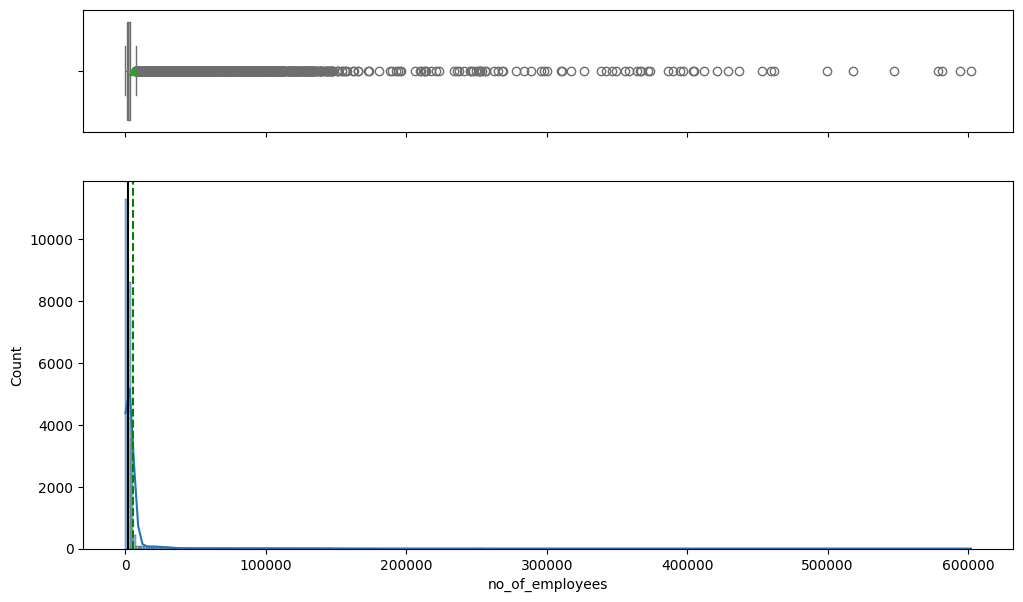

In [ ]:
histogram_boxplot(data, 'no_of_employees', kde=True);

- The distribution is heavily **right-skewed (positively skewed)**.

- There are a massive number of **outliers** on the upper end, extending all the way to **600,000** employees.

- Majority of the applicants(~25,000) are from **small companies** with employee count of **~3500**.

#### Prevailing Wage

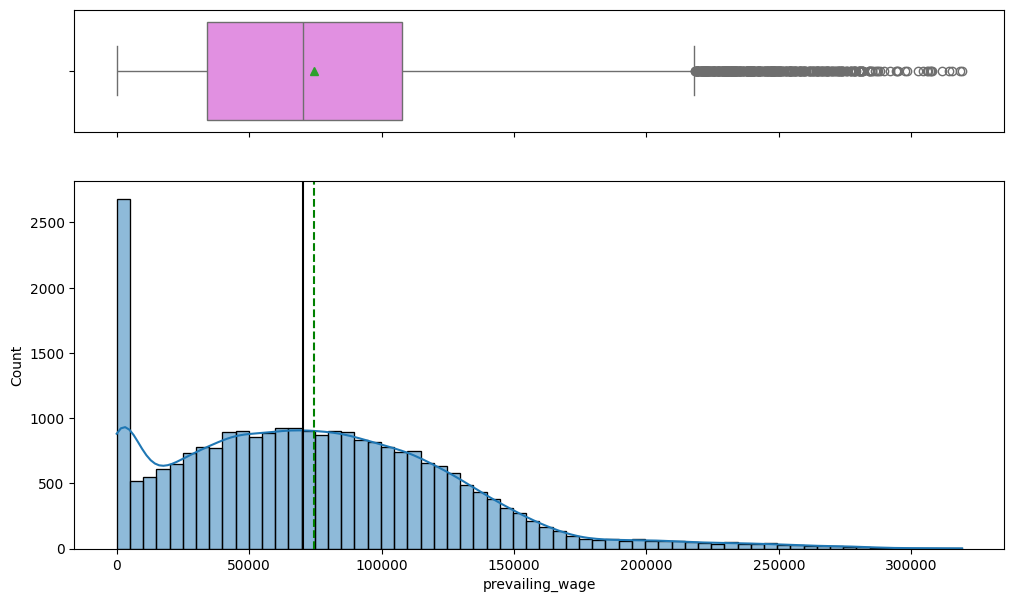

In [ ]:
histogram_boxplot(data, 'prevailing_wage', kde=True);

- The distribution exhibits **right skewness** with a notable **bimodal** pattern . There’s an extreme spike at the lowest wage bin (around 0-10,000, with approximately 2,700 entries), followed by a secondary mode around 50,000-90,000 where the distribution shows relatively sustained frequency before gradually declining.

- From the boxplot, 50% of the data falls within the range of **30K to 110K** with an average prevailing_wage around **75K**.

- There are **outliers** with high wage values resulting in right skewed distribution.

#### Company Age

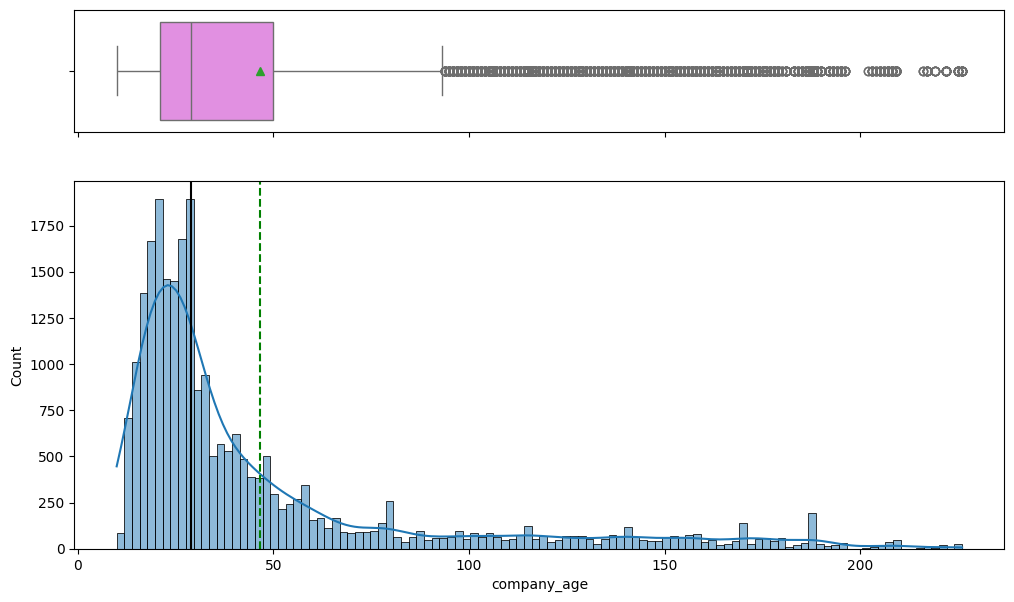

In [ ]:
histogram_boxplot(data, 'company_age', kde=True);

- The distribution is **strongly right-skewed**, most companies are relatively young, with a high concentration of firms aged between 15 and 30 years..

- The distribution features a long tail of "legacy" companies, with several **outliers** exceeding 150 to 200 years of operation.

- The **median** age (approx. 25 years) is **lower** than the **mean** (approx. 45 years), suggesting that newer companies are more active in the visa application process than very old establishments.

### Categorical Features

#### Continent

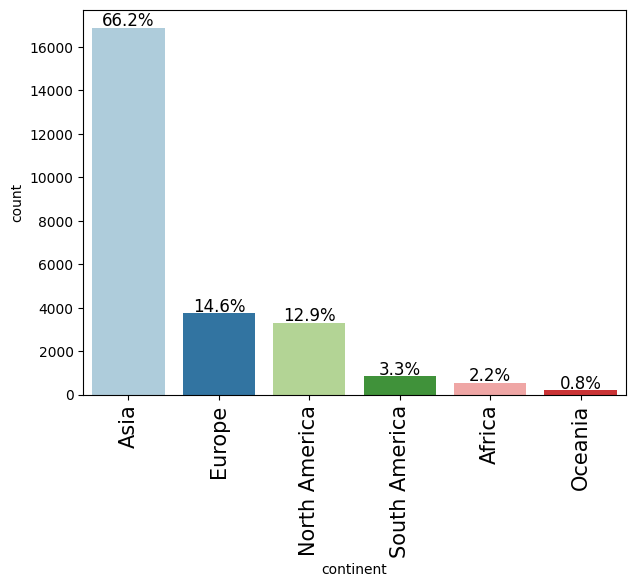

In [ ]:
labeled_barplot(data, 'continent', perc=True);

- **Asia** is the primary source of visa applicants, accounting for a significant majority at **66.2%**.

- **Europe (14.6%)** and **North America (12.9%)** follow as the next largest contributors.

- **South America**, **Africa**, and **Oceania** combined represent less than **7%** of the total applications, indicating a highly skewed geographic distribution.

#### Education of Employee

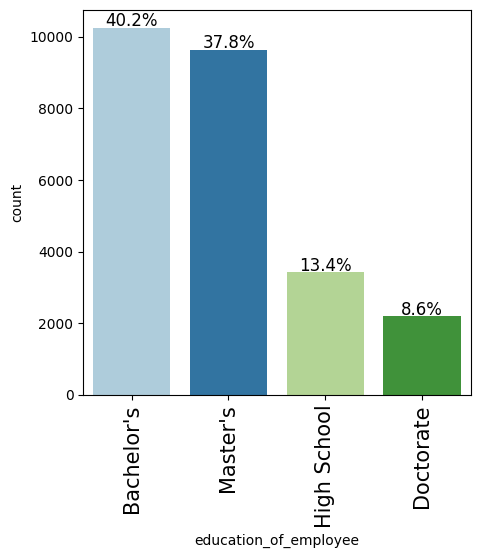

In [ ]:
labeled_barplot(data, 'education_of_employee', perc=True);

- A significant majority of applicants hold advanced degrees, with **Bachelor's (40.2%)** and **Master's (37.8%)** combined making up **78%** of the total applications.

- Employees with a **Bachelor's degree** represent the largest segment of the applicant pool, exceeding 10,000 cases.

- Applicants with only a **High School** education are relatively few, accounting for only **13.4%** of the data.

- **Doctorate** holders represent the smallest category at **8.6%**, suggesting that while highly qualified, they form a niche segment of the labor certification requests.

- The distribution is **heavily skewed towards degree-holders**, which aligns with the typical requirements for temporary and permanent labor certifications in the US.

#### Has Job Experience

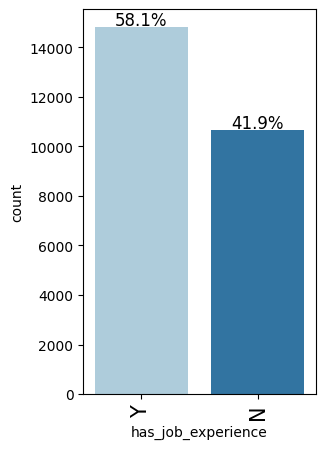

In [ ]:
labeled_barplot(data, 'has_job_experience', perc=True);

- More than half of the applicants (**58.1%**) possess prior job experience.

- A significant portion of the pool (**41.9%**) does not have prior job experience, indicating a healthy influx of entry-level candidates or recent graduates.

- The dataset has a fairly **balanced distribution** of experienced and fresh talent.

#### Requires Job Training

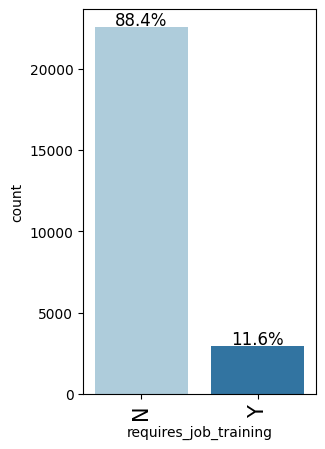

In [ ]:
labeled_barplot(data, 'requires_job_training', perc=True);

- The vast majority of applicants (**88.4%**) do not require job training, suggesting that employers are largely hiring candidates who are already proficient in their roles.

- Only **11.6%** of positions require additional training, which might imply that the visas are primarily for skilled roles where immediate productivity is expected.

#### Region of Employment

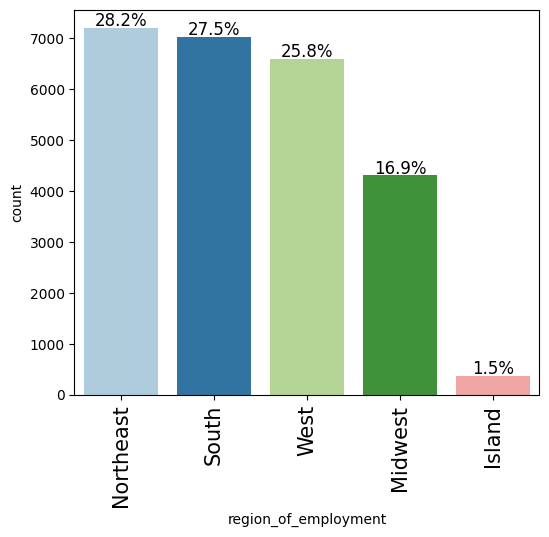

In [ ]:
labeled_barplot(data, 'region_of_employment', perc=True);

- The **Northeast** region has the highest number of visa applications, accounting for **28.2%** of the total.

- The **South** and **West** regions follow closely, representing **27.5%** and **25.8%** of the applications, respectively.

- Together, the Northeast, South, and West regions constitute the vast majority of the data, totaling over **80%** of all applications.

- The **Midwest** represents a significantly smaller portion of the applications at **16.9%**.

- The **Island** region has the least representation by a wide margin, accounting for only **1.5%** of the processed applications.

#### Unit of Wage

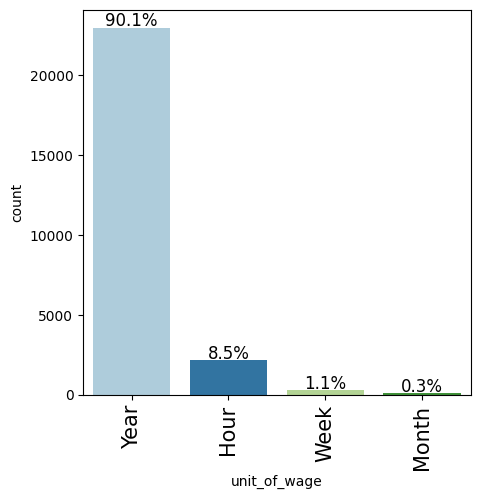

In [ ]:
labeled_barplot(data, 'unit_of_wage', perc=True);

- The vast majority of employers (**90.1%**) specify the prevailing wage on a **Yearly** basis.

- **Hourly** wages are the second most common but account for a much smaller portion at **8.5%**.

- **Weekly (1.1%)** and **Monthly (0.3%)** wage units are rarely used in the application process.

#### Full Time Position

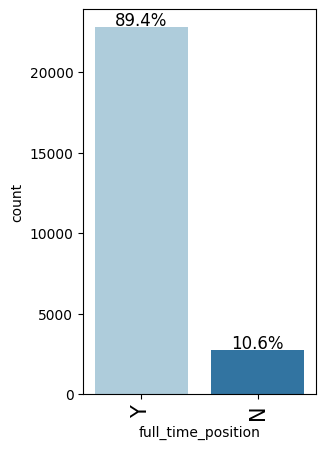

In [ ]:
labeled_barplot(data, 'full_time_position', perc=True);

- A vast majority of visa applications, **89.4%**, are for **full-time** positions.

- Only **10.6%** of the applications are for **part-time** positions.

- There is a significant **class imbalance** in this feature, with full-time applications outnumbering part-time ones by nearly **9 to 1**.

#### Case Status

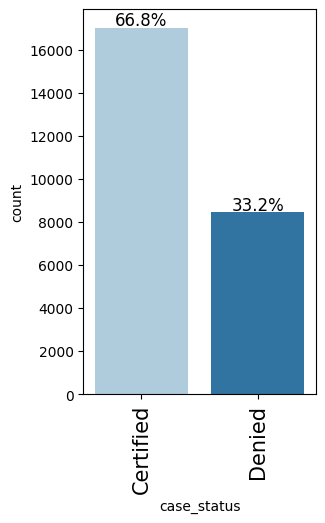

In [ ]:
labeled_barplot(data, 'case_status', perc=True);

- Roughly **two-thirds (66.8%)** of the visa applications in the dataset were **Certified**.

- Approximately **one-third (33.2%)** of the applications were **Denied**.

- There is a **2:1 ratio** between certified and denied cases, which represents a **mild class imbalance** for the classification model to address.

## Bivariate Analysis

In [ ]:
# function to create a crosstab and plot a stacked bar chart

def plot_stacked_bar(data, row_feat, col_feat):
    # creating a crosstab
    tab = pd.crosstab(
        data[row_feat],
        data[col_feat].astype(str),
        normalize='index'    # normalizing by dividing each row by its row total
    )

    # Plot the stacked bar chart
    tab.plot(kind='bar', stacked=True, figsize=(7, 5))    # creating a stacked bar chart from the normalized crosstab
    plt.xlabel(row_feat);    # adding x-axis label
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title=col_feat);    # adding a legend for the col_feat column
    plt.show()

#### Correlation

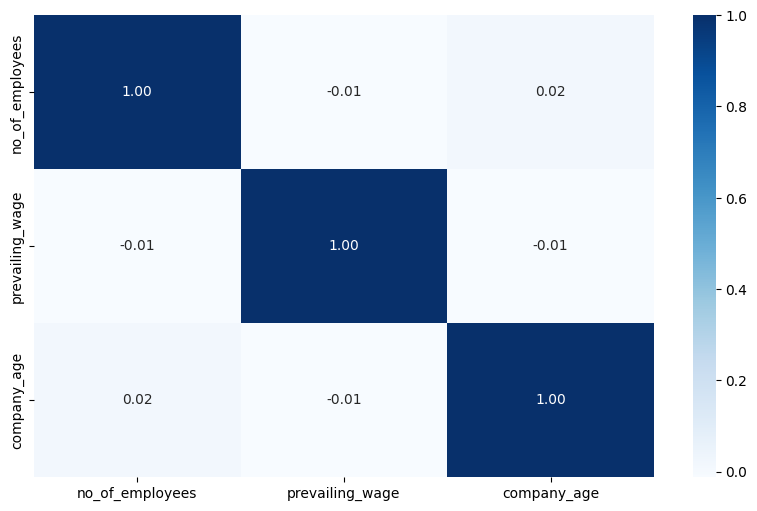

In [ ]:
# plot correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='Blues', fmt='.2f')
plt.show()

- **Negligible Linear Relationship**: There is no significant linear correlation between **no_of_employees**, **prevailing_wage**, and **company_age**, as all off-diagonal correlation coefficients are near zero (ranging from -0.01 to 0.02).

- **Multicollinearity**: The lack of correlation between these features suggests that there is no risk of multicollinearity among these specific numerical variables when building the classification model.

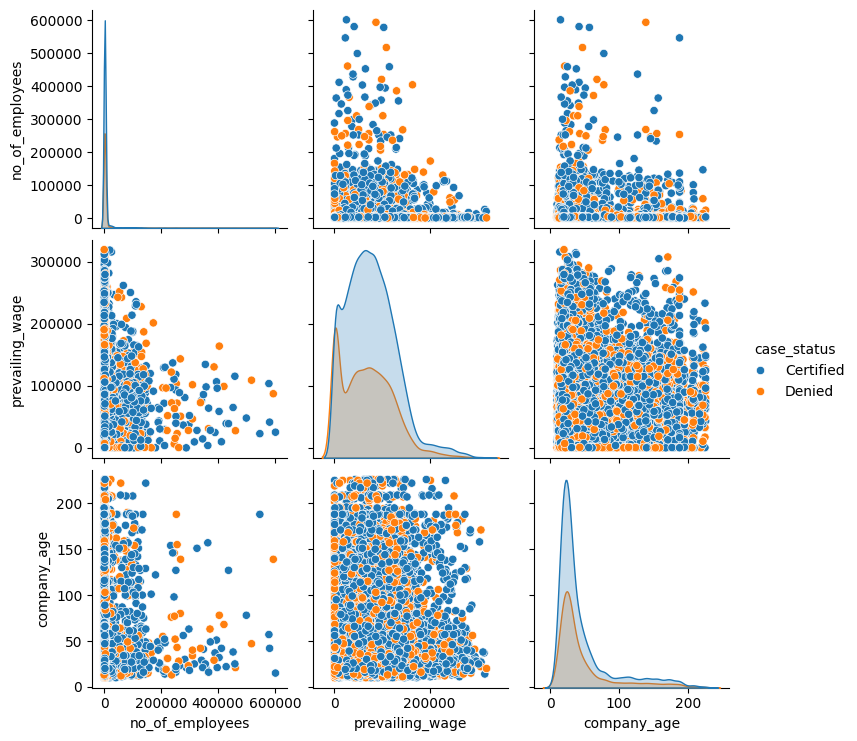

In [ ]:
# pairplot to visualize relationships between numerical features by case_status
sns.pairplot(data, hue='case_status', diag_kind='kde')
plt.show()

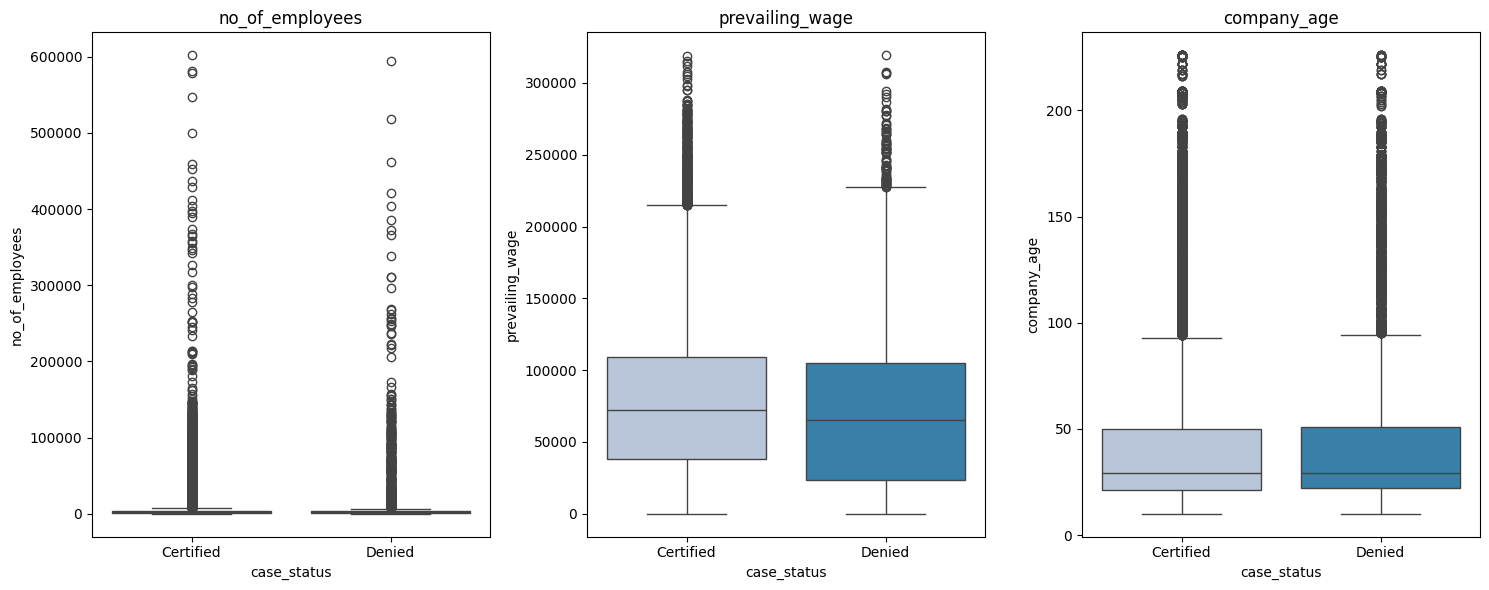

In [ ]:
# boxplots to visualize numerical features by case_status
num_cols = data.select_dtypes(include='number').columns
plt.figure(figsize=(15, 6))
for i, variable in enumerate(num_cols):
    plt.subplot(1,3,i+1)
    sns.boxplot(data=data, x='case_status', y=variable, palette="PuBu")
    plt.tight_layout()
    plt.title(variable)
plt.show()

#### Number of Employees vs Case Status
- The distribution of the number of employees is very similar for both Certified and Denied cases.

- Both categories have a large number of outliers (very large companies), but the median and interquartile ranges are almost identical.

- Company size (number of employees) does not significantly influence visa approval rates. Larger companies do not have a noticeably higher approval rate compared to smaller ones.

#### Prevailing Wage vs Case Status
- The median prevailing wage is higher for Certified cases compared to Denied cases.

- However, there is substantial overlap in the wage distributions for both Certified and Denied cases, with both showing a wide range and many outliers.

- Higher prevailing wages are associated with a slightly higher chance of approval, but prevailing wage alone is not a strong discriminator—many denied cases also have high wages.

#### Company Age vs Case Status
- The distribution of company ages is very similar for both Certified and Denied cases.

- The median and interquartile range (IQR) for company age are almost identical between the two groups.

- Both Certified and Denied applications include companies of all ages, from very young to very old, with no clear separation.

- There are many outliers (very old companies) in both groups, but these do not appear to influence approval rates.

- Company age does not significantly influence visa approval rates. Both new and old companies have similar chances of visa certification, and company age is not a strong predictor of approval outcome.

#### Continent vs Case Status

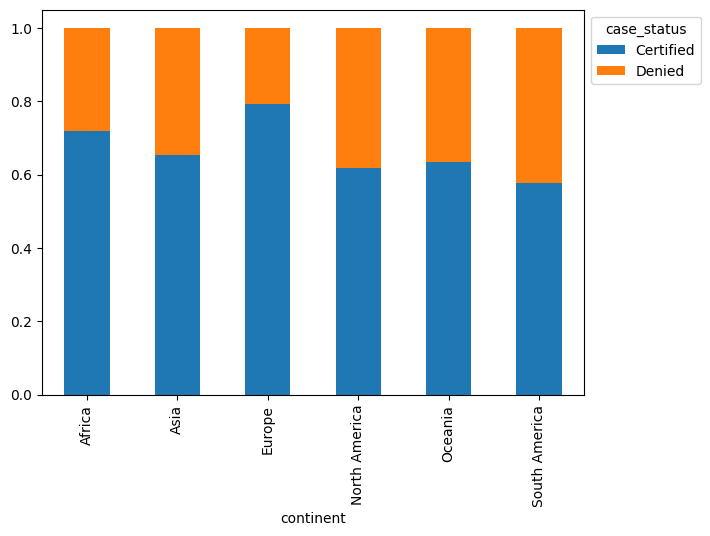

In [ ]:
plot_stacked_bar(data, 'continent', 'case_status');

- There is a noticeable difference in certification rates across continents. This can be a significant driver for classification.

- **High Approval Regions**: Applicants from **Europe and Africa** show the **highest certification rates**, with Europe leading at nearly 80% approval.

- **Moderate Approval Regions**: **Asia, Oceania, and North America** share similar trends, with certification rates hovering between 60% and 70%.

- **Lowest Approval Region**: **South America** has the **highest proportion of denials**, with the certification rate falling below 60%.

#### Education of Employee vs Case Status

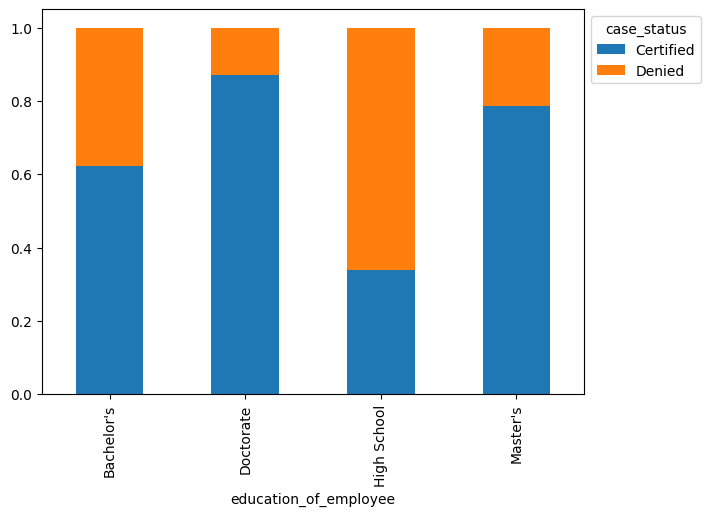

In [ ]:
plot_stacked_bar(data, 'education_of_employee', 'case_status');

- **Direct Correlation with Higher Education**: There is a clear **positive correlation** between the level of education and the likelihood of visa certification.

- **Top Performance**: Applicants with a **Doctorate** have the **highest certification rate**, exceeding **85%**.

- **Strong Performance**: Those with a **Master's degree** follow closely with an approval rate of approximately **80%**.

- **Baseline Professional**: Applicants with a **Bachelor's degree** have a certification rate of roughly **60%**.

- **High Risk Category**: Applicants with only a **High School education** face the **highest denial rates**, with only about **35%** of cases being certified.

#### Has Job Experience vs Case Status

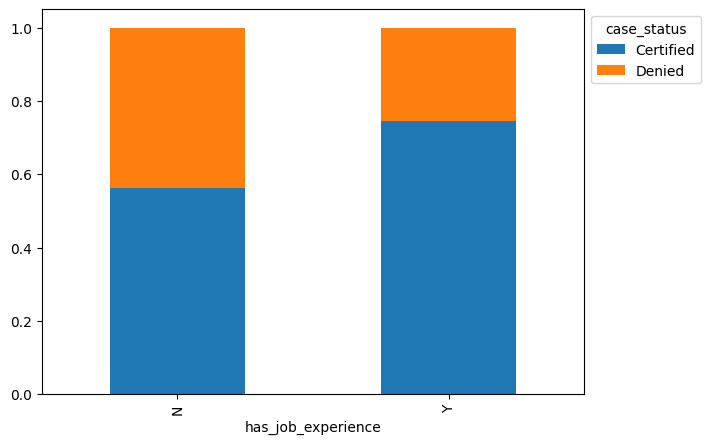

In [ ]:
plot_stacked_bar(data, 'has_job_experience', 'case_status');

- **Job Experience as a Major Driver**: There is a significant disparity in approval rates based on experience.  
Applicants with prior job experience have a certification rate of approximately **70%**, whereas those without experience see a drop to roughly **35-40%**.

#### Requires Job Training vs Case Status

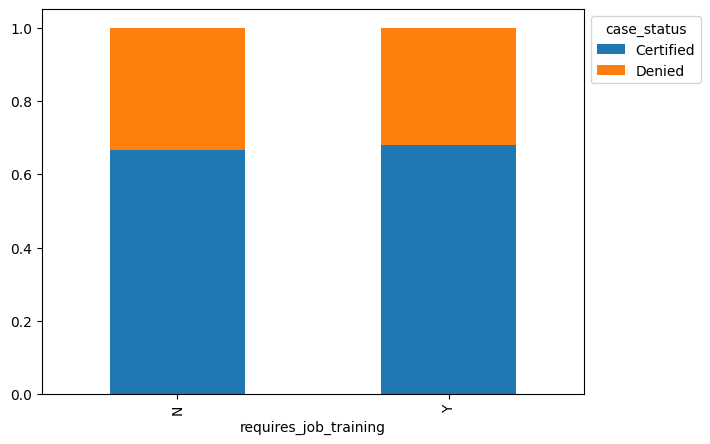

In [ ]:
plot_stacked_bar(data, 'requires_job_training', 'case_status');

- **Minimal Impact of Training**: Interestingly, the requirement for job training does not strongly influence the outcome.  
Certification rates remain relatively stable (around 65-68%) whether or not training is required by the employer.

#### Region of Employment vs Case Status

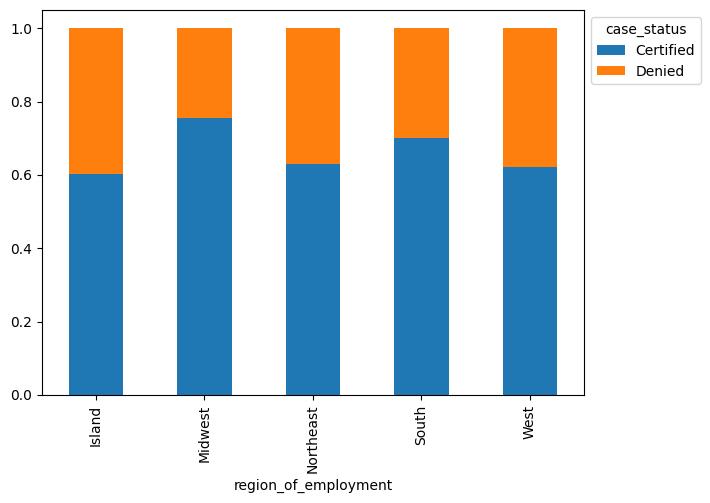

In [ ]:
plot_stacked_bar(data, 'region_of_employment', 'case_status');

- **Highest Approval Rate**: The **Midwest** region has the **highest** proportion of "Certified" visa applications compared to other regions.

- **Consistent Denial Rates**: The **Island, Northeast, and West** regions show very similar distributions, with roughly **60-65%** of applications being certified and **35-40%** being denied.

- The region of employment does appear to influence the probability of certification, with the **South** also showing a slightly higher certification rate than the **West** or **Northeast**.

#### Unit of Wage vs Case Status

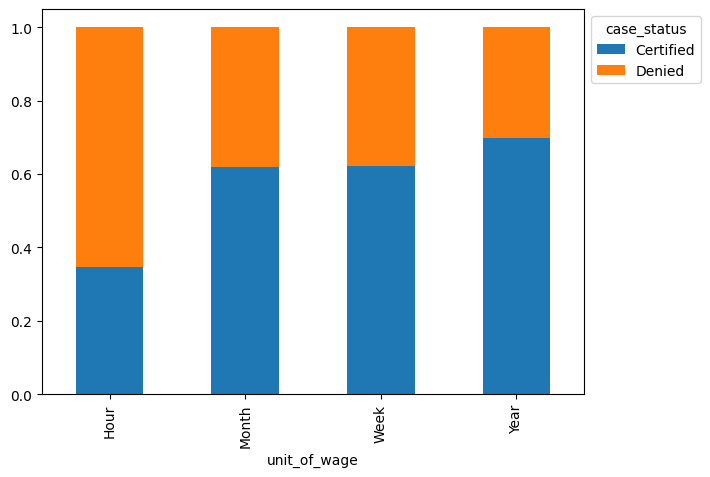

In [ ]:
plot_stacked_bar(data, 'unit_of_wage', 'case_status');

- **Hourly** wages have the lowest certification rate, with approximately **65%** of applications in this category being **Denied**.

- **Yearly** wages show the highest likelihood of approval, with a certification rate of approximately **70%**.

- Applications with **Monthly** and **Weekly** wage units show very similar distribution patterns, both having a certification rate of roughly **62%**.

- There is a clear positive correlation between longer-term wage units (Yearly) and the probability of visa certification compared to short-term units (Hourly).

#### Full Time Position vs Case Status

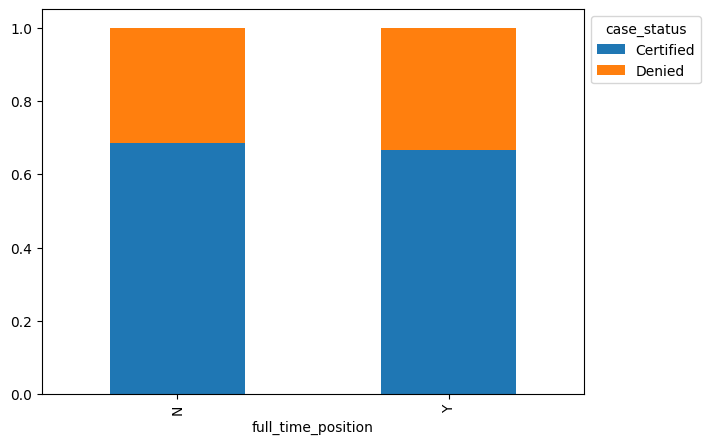

In [ ]:
plot_stacked_bar(data, 'full_time_position', 'case_status');

- **Full-time** roles have a slightly higher certification rate compared to **part-time** roles.

- There might be negligible impact of this feature on the final case status.

**Leading Questions**
1. What is the distribution of visa case statuses (certified vs. denied)?
    - **The dataset shows a mild class imbalance:** **~66.8%** of applications are Certified and **~33.2%** are Denied (roughly a **2:1** ratio).

2. How does the education level of employees impact visa approval rates?
    - Approval rates **increase** with education level. **Doctorate** holders have the highest certification rate (**>85%**), followed by **Master’s (80%)**, **Bachelor’s (60%)**, and **High School (lowest, ~35% certified)**. Higher education is strongly associated with higher approval.

3. Is there a significant difference in visa approval rates between employees with and without prior job experience?
    - Applicants with prior job experience have a much higher certification rate (**70%**) compared to those without experience (**35–40%**). Job experience is a major driver for approval.

4. How does the prevailing wage affect visa approval? Do higher wages lead to higher chances of approval?
    - Higher prevailing wages are associated with a slightly higher chance of approval, but prevailing wage alone is not a strong discriminator—many denied cases also have high wages.

5. Do certain regions in the US have higher visa approval rates compared to others?
    - The **Midwest** region has the highest certification rate. The **Island**, **Northeast**, and **West** regions have similar approval rates (**~60–65%**). The **South** is slightly higher than **West/Northeast**. Region of employment does influence approval probability.

6. How does the number of employees in a company influence visa approval? Do larger companies have a higher approval rate?
    - Company size (number of employees) does not significantly influence visa approval rates. Larger companies do not have a noticeably higher approval rate compared to smaller ones.

7. Are visa approval rates different across various continents of employees? Which continent has the highest and lowest approval rates?
    - Approval rates vary significantly by continent.  
    **Europe** has the highest certification rates (**~80%**).   
    **South America** has the lowest approval rate (**<60%**), with the highest proportion of **denials**.


# **Data Pre-processing**

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

## Data Preparation for Modelling

In [ ]:
# split data into features and target variable
X = data.drop('case_status', axis=1)
y = data['case_status']

In [ ]:
# split dataset into training, validation and test sets
# first split into temp and test sets
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# split temp set into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)  # 0.25 x 0.8 = 0.2

In [ ]:
# check the shapes of the splits
X_train.shape, X_val.shape, X_test.shape

((15288, 10), (5096, 10), (5096, 10))

## Missing Value Treatement

- There are no missing values in the dataset.

## Feature Engineering

**Below operations are already performed under Basic Cleanup and Formatting**

- Dropped case_id column as it is unique identifier and doesn't add value to analysis/model building.

- Company age is derived from year of establishment and original column is dropped.

- Categorical columns are converted to category data type for memory optimization.

## Outlier Detection and Treatement

- no_of_Employees contains negative values, let's review the negative values and treat them.

- Both no_of_employees and prevailing_Wage contains significant outliers. Boosting models can handle the outliers, we can either Cap or leave the outliers as is.

- Let's apply a small percentile cap in this case to remove extreme noise.

### Rectify Negative Values

In [ ]:
# check the unique negative values in no_of_employees
X_train[X_train['no_of_employees'] < 0]['no_of_employees'].unique()

array([-11, -26, -25, -17, -14])

In [ ]:
# check the min positive value in no_of_employees
X_train[X_train['no_of_employees'] > 0]['no_of_employees'].min()

np.int64(12)

- 12 is the minimum positive value in no_of_employees.

- Looking at the negative numbers, there can be sign error. Assuming the negative values to be sign error, will replace them with absolute values.

In [ ]:
# rectify negative values in no_of_employees by taking absolute value
X_train['no_of_employees'] = X_train['no_of_employees'].abs()
X_val['no_of_employees'] = X_val['no_of_employees'].abs()
X_test['no_of_employees'] = X_test['no_of_employees'].abs()

In [ ]:
# verify that there are no negative values left
print(
    X_train[X_train['no_of_employees'] < 0]['no_of_employees'].unique(),
    X_val[X_val['no_of_employees'] < 0]['no_of_employees'].unique(),
    X_test[X_test['no_of_employees'] < 0]['no_of_employees'].unique()
)

[] [] []


### Outlier Treatement - Capping

In [ ]:
# cap the no_of_employees at 99th percentile using the percentile from training set
upper_cap_value = X_train['no_of_employees'].quantile(0.99)
X_train['no_of_employees'] = X_train['no_of_employees'].clip(upper=upper_cap_value)
X_val['no_of_employees'] = X_val['no_of_employees'].clip(upper=upper_cap_value)
X_test['no_of_employees'] = X_test['no_of_employees'].clip(upper=upper_cap_value)

In [ ]:
# cap the prevailing_wage at 99th percentile using the percentile from training set
upper_cap_value_wage = X_train['prevailing_wage'].quantile(0.99)
X_train['prevailing_wage'] = X_train['prevailing_wage'].clip(upper=upper_cap_value_wage)
X_val['prevailing_wage'] = X_val['prevailing_wage'].clip(upper=upper_cap_value_wage)
X_test['prevailing_wage'] = X_test['prevailing_wage'].clip(upper=upper_cap_value_wage)

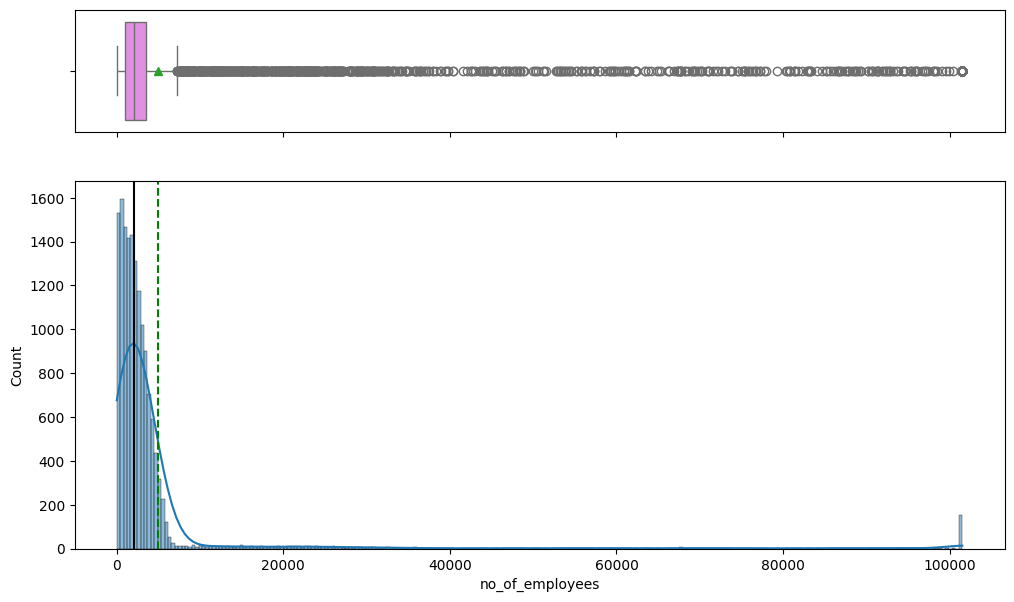

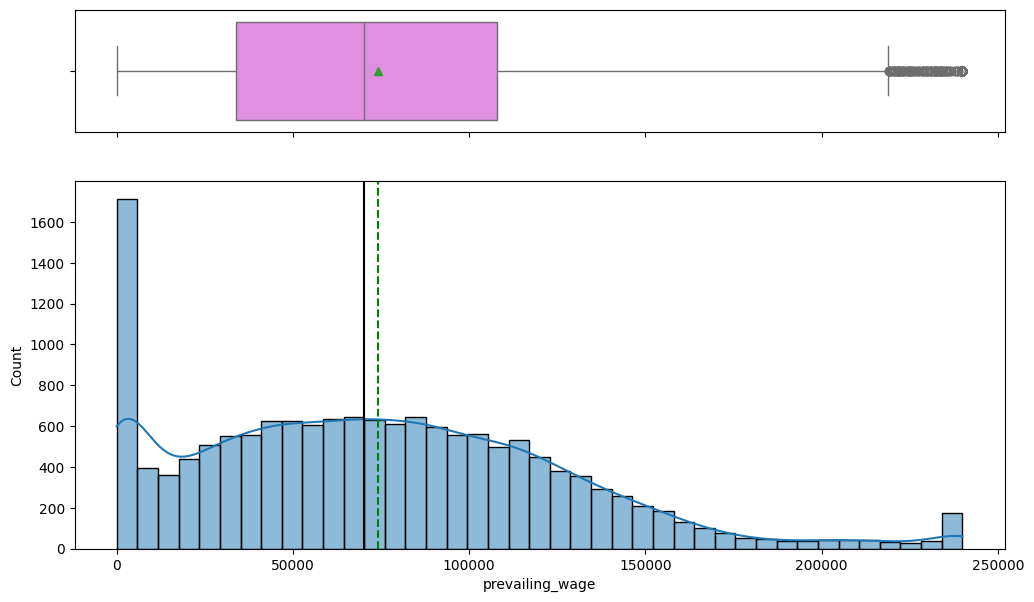

In [ ]:
# check the distribution of no_of_employees and prevailing_wage after rectification and capping
histogram_boxplot(X_train, 'no_of_employees', kde=True);
histogram_boxplot(X_train, 'prevailing_wage', kde=True);

- We can still see the outliers as we applied cap at 99th percentile considering the high values are valid scenarios. With small capping we can reduce the impact of outliers on the model without losing valuable information.

## Encoding Categorical Variables

Will apply one hot encoding for nominal features and label encoding for ordinal features and target variable.

- One Hot Encoding:  
    - continent
    - has_job_experience
    - requires_job_training
    - region_of_employment
    - unit_of_wage
    - full_time_position  

- Label Encoding:  
    - education_of_employee
    - case_status  

In [ ]:
# apply one-hot encoding for nominal features
nominal_cols = ['continent', 'has_job_experience', 'requires_job_training',
                'region_of_employment', 'unit_of_wage', 'full_time_position']

X_train = pd.get_dummies(X_train, columns=nominal_cols, drop_first=True)
X_val = pd.get_dummies(X_val, columns=nominal_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=nominal_cols, drop_first=True)

In [ ]:
# apply label encoding for ordinal feature 'education_of_employee'
edu_map = {'High School': 0, "Bachelor's": 1, "Master's": 2, 'Doctorate': 3}
X_train['education_of_employee'] = X_train['education_of_employee'].map(edu_map)
X_val['education_of_employee'] = X_val['education_of_employee'].map(edu_map)
X_test['education_of_employee'] = X_test['education_of_employee'].map(edu_map)

# update the dtype of 'education_of_employee' to integer
X_train['education_of_employee'] = X_train['education_of_employee'].astype('int')
X_val['education_of_employee'] = X_val['education_of_employee'].astype('int')
X_test['education_of_employee'] = X_test['education_of_employee'].astype('int')

In [ ]:
# apply label encoding for target variable
target_map = {'Denied': 0, 'Certified': 1}
y_train = y_train.map(target_map)
y_val = y_val.map(target_map)
y_test = y_test.map(target_map)

# update the dtype of target variable to integer
y_train = y_train.astype('int')
y_val = y_val.astype('int')
y_test = y_test.astype('int')

In [ ]:
# check the data shapes after preprocessing
print("Training data:", X_train.shape, y_train.shape)
print("Validation data:", X_val.shape, y_val.shape)
print("Test data:", X_test.shape, y_test.shape)

Training data: (15288, 19) (15288,)
Validation data: (5096, 19) (5096,)
Test data: (5096, 19) (5096,)


- There are 19 feature columns in the training, validation and test datasets after pre-processing and encoding.

# **Model Building**

### Model Evaluation Criteria

#### Model can make wrong predictions as:

- **False Positive (Predicting Certified when it should be Denied)**: The model incorrectly approves a visa that fails to meet statutory requirements. This risks displacing US workers or suppressing local wages, violating the INA (Immigration and Nationality Act).

- **False Negative (Predicting Denied when it should be Certified)**: The model flags a valid application for rejection. This increases administrative burden, as employers will likely appeal or re-file, leading to more manual labor for OFLC officers.

#### Which case is more important?

- **Predicting Certified but in reality, it is Denied (False Positive)** remains the more critical error for the OFLC as a regulatory body. Protecting the US labor market is their primary legal mandate.

- **However**, if the model has too many **False Negatives**, it fails to solve the "tedious task" problem because officers would still be buried under a mountain of manual reviews and appeals.

#### How to balance these using the F1-Score?

- **F1-Score** is the harmonic mean of **Precision** and **Recall**.

- In this scenario, we use the **F1-Score** to ensure the model is a "functional assistant":

    - **Precision** ensures that when the model says "Certified," the officer can trust that decision (protecting the labor market).

    - **Recall** ensures that the model is actually identifying a large portion of the certifiable cases (reducing the manual workload).

### User Defined Funtions

Let's build re-usable functions to:
- Calculate model scoring metrics

- Plot confusion matrix

- Train and Validate different models

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
# function to plot confusion matrix with percentages
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

In [ ]:
# function to train and validate different models and store their performance metrics
def train_validate_models(models, X_train, y_train, X_val, y_val):
    """
    Function to train and validate different models and store their performance metrics

    models: list of tuples containing model name and model object
    X_train: training features
    y_train: training target
    X_val: validation features
    y_val: validation target
    """

    # initialize empty dataframe to store training and validation scores
    model_scores = pd.DataFrame()

    # train the models and evaluate performance on training and validation sets
    for name, model in models:
        # train the model
        model.fit(X_train, y_train)

        # get training scores
        train_scores = model_performance_classification_sklearn(model, X_train, y_train)

        # rename columns in the train_scores dataframe
        train_scores.rename(
            columns={
                'Accuracy': 'Train_Accuracy',
                'Recall': 'Train_Recall',
                'Precision': 'Train_Precision',
                'F1': 'Train_F1'
            },
            inplace=True
        )

        # insert model name into the train_scores dataframe
        train_scores.insert(0, 'Model', name)

        # get validation scores
        val_scores = model_performance_classification_sklearn(model, X_val, y_val)

        # rename columns in the val_scores dataframe
        val_scores.rename(
            columns={
                'Accuracy': 'Val_Accuracy',
                'Recall': 'Val_Recall',
                'Precision': 'Val_Precision',
                'F1': 'Val_F1'
            },
            inplace=True
        )

        # insert model name into the val_scores dataframe
        val_scores.insert(0, 'Model', name)

        # add training and validation scores to the model_scores dataframe by model name
        model_scores = pd.concat(
            [
                model_scores,
                pd.merge(train_scores, val_scores, on='Model')
            ],
            ignore_index=True
        )

    # calculate f1 difference between training and validation scores
    model_scores['F1_Diff'] = model_scores['Train_F1'] - model_scores['Val_F1']

    # return the model scores df
    return model_scores

## Model Building - Original Data

In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("DTree", DecisionTreeClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1), random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))

# train and validate models and get their performance metrics
init_model_scores_df = train_validate_models(models, X_train, y_train, X_val, y_val)
init_model_scores_df

,Model,Train_Accuracy,Train_Recall,Train_Precision,Train_F1,Val_Accuracy,Val_Recall,Val_Precision,Val_F1,F1_Diff
0,DTree,1.000000,1.000000,1.000000,1.000000,0.666797,0.757051,0.747390,0.752189,0.247811
1,Random forest,1.000000,1.000000,1.000000,1.000000,0.729003,0.851351,0.768089,0.807580,0.192420
2,Bagging,0.983713,0.983448,0.992096,0.987753,0.700942,0.779671,0.774212,0.776932,0.210821
3,GBM,0.758176,0.883252,0.782609,0.829890,0.751766,0.880435,0.777432,0.825734,0.004156
4,Adaboost,0.739600,0.889716,0.760868,0.820263,0.739992,0.892773,0.759940,0.821019,-0.000756


- **GBM (Gradient Boosting)** and **Adaboost** classifiers have the best performance with F1 score of **~0.82**. The difference between train and validation F1 scores is minimum for these models.

- **Decision Tree**, **Random forest** and **Bagging** models clearly exhibit overfitting with high scores on training data and low scores on validation dataset.

## Model Building - Oversampled Data

In [ ]:
print("Label counts before Oversampling:")
print("Certified: {}".format(sum(y_train == 1)))
print("Denied: {} \n".format(sum(y_train == 0)))

# Oversampling by Synthetic Minority Over Sampling Technique
sm = SMOTE(
    sampling_strategy=1, k_neighbors=5, random_state=1
)
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("Label counts after Oversampling:")
print("Certified: {}".format(sum(y_train_over == 1)))
print("Denied: {} \n".format(sum(y_train_over == 0)))

print("Dataset shapes after Oversampling:")
print("X_train_over: {}".format(X_train_over.shape))
print("y_train_over: {} \n".format(y_train_over.shape))

Label counts before Oversampling:
Certified: 10210
Denied: 5078 

Label counts after Oversampling:
Certified: 10210
Denied: 10210 

Dataset shapes after Oversampling:
X_train_over: (20420, 19)
y_train_over: (20420,) 



In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("DTree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))

# train and validate models and get their performance metrics
oversample_model_scores_df = train_validate_models(models, X_train_over, y_train_over, X_val, y_val)
oversample_model_scores_df

,Model,Train_Accuracy,Train_Recall,Train_Precision,Train_F1,Val_Accuracy,Val_Recall,Val_Precision,Val_F1,F1_Diff
0,DTree,1.000000,1.000000,1.000000,1.000000,0.656005,0.726204,0.750683,0.738241,0.261759
1,Random forest,1.000000,1.000000,1.000000,1.000000,0.722527,0.818449,0.777778,0.797595,0.202405
2,Bagging,0.985113,0.977473,0.992640,0.984998,0.686421,0.743537,0.777334,0.760060,0.224938
3,GBM,0.791626,0.871401,0.751499,0.807021,0.748823,0.876028,0.776563,0.823302,-0.016281
4,Adaboost,0.752351,0.761704,0.747717,0.754646,0.700353,0.766157,0.781072,0.773543,-0.018897


- **GBM (Gradient Boosting)** has the best perfomance with oversampled dataset followed by **Adaboost**. The validation F1 score of GBM on oversampled data is similar to that of original data.

- The train and validation F1 scores of **Adaboost** model reduced slightly on oversampled data as compared to that of original data.

- **Decision Tree**, **Random Forest** and **Bagging** classifiers remain overfitted on oversampled data.

## Model Building - Undersampled Data

In [ ]:
print("Label counts before Undersampling:")
print("Certified: {}".format(sum(y_train == 1)))
print("Denied: {} \n".format(sum(y_train == 0)))

# Undersampling by Random Under Sampling
rus = RandomUnderSampler(random_state=1)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)


print("Label counts after Undersampling:")
print("Certified: {}".format(sum(y_train_under == 1)))
print("Denied: {} \n".format(sum(y_train_under == 0)))

print("Dataset shapes after Undersampling:")
print("X_train_under: {}".format(X_train_under.shape))
print("y_train_under: {} \n".format(y_train_under.shape))

Label counts before Undersampling:
Certified: 10210
Denied: 5078 

Label counts after Undersampling:
Certified: 5078
Denied: 5078 

Dataset shapes after Undersampling:
X_train_under: (10156, 19)
y_train_under: (10156,) 



In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("DTree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))

# train and validate models and get their performance metrics
undersample_model_scores_df = train_validate_models(models, X_train_under, y_train_under, X_val, y_val)
undersample_model_scores_df

,Model,Train_Accuracy,Train_Recall,Train_Precision,Train_F1,Val_Accuracy,Val_Recall,Val_Precision,Val_F1,F1_Diff
0,DTree,1.000000,1.000000,1.000000,1.000000,0.622841,0.625147,0.767123,0.688896,0.311104
1,Random forest,0.999803,0.999606,1.000000,0.999803,0.687794,0.685664,0.817513,0.745806,0.253997
2,Bagging,0.979618,0.967113,0.991921,0.979360,0.639129,0.604289,0.806983,0.691080,0.288280
3,GBM,0.721445,0.745569,0.711253,0.728007,0.720369,0.733843,0.827975,0.778072,-0.050065
4,Adaboost,0.685998,0.761323,0.661646,0.707994,0.710165,0.762338,0.795280,0.778461,-0.070467


- **GBM** and **Adaboost** have the best performance on undersampled data. But, the F1 scores are reduced as compared to initial models trained on original data.

- **Decision Tree**, **Random Forest** and **Bagging** classifiers still remain overfitted on undersampled data as well.

# **Model Performance Improvement**

## Hyperparameter Tuning

### Models Selection for Tuning

- Based on the performance metrics from 15 models in the preivous section, it was observed that the **GBM** and **Adaboost** trained on original dataset, as well as the **GBM** trained on oversampled dataset, exhibited the strong performance on both training and validation datasets.

- **Adaboost** had a small dip in F1 score on oversampled dataset compared to the model trained on original data. However, it was still the second best performer on oversampled dataset.

- Therefore, we will choose these 4 models for tuning:
    1. **GBM** on Orginal Dataset

    2. **Adaboost** on Original Dataset

    3. **GBM** on Oversampled Dataset

    4. **Adaboost** on Oversampled Dataset


### Tuning GBM on Original Dataset

In [ ]:
%%time

#defining model
Model = GradientBoostingClassifier(random_state=1)

#Parameter grid to pass in RandomSearchCV
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = -1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train,y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.7, 'n_estimators': np.int64(75), 'max_features': 0.7, 'learning_rate': 0.05, 'init': AdaBoostClassifier(random_state=1)} with CV score=0.8245245781827318:
CPU times: user 1.35 s, sys: 459 ms, total: 1.81 s
Wall time: 27.6 s


In [ ]:
# train the GBM on original training data with best parameters from RandomizedSearchCV
tuned_gbm_org = GradientBoostingClassifier(
    random_state=1,
    subsample=0.7,
    n_estimators=75,
    max_features=0.7,
    learning_rate=0.05,
    init=AdaBoostClassifier(random_state=1),
)
tuned_gbm_org.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.05
,n_estimators,75
,subsample,0.7
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,AdaBoostClass...andom_state=1)


In [ ]:
# Checking model's performance on training set
gbm_org_train_perf = model_performance_classification_sklearn(
    tuned_gbm_org, X_train, y_train
)
gbm_org_train_perf

,Accuracy,Recall,Precision,F1
0,0.751504,0.886974,0.773951,0.826617


In [ ]:
# Checking model's performance on validation set
gbm_org_val_perf = model_performance_classification_sklearn(tuned_gbm_org, X_val, y_val)
gbm_org_val_perf

,Accuracy,Recall,Precision,F1
0,0.749608,0.889835,0.770738,0.826016


### Tuning Adaboost on Original Dataset

In [ ]:
%%time

# defining model
Model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_jobs = -1, n_iter=50, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train, y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': np.int64(50), 'learning_rate': 0.1, 'estimator': DecisionTreeClassifier(max_depth=3, random_state=1)} with CV score=0.8224085597577957:
CPU times: user 888 ms, sys: 143 ms, total: 1.03 s
Wall time: 14.3 s


In [ ]:
# training the AdaBoost model on original training data with best parameters from RandomizedSearchCV
tuned_adb_org = AdaBoostClassifier(
    random_state=1,
    n_estimators=50,
    learning_rate=0.1,
    estimator=DecisionTreeClassifier(max_depth=3, random_state=1),
)
tuned_adb_org.fit(X_train, y_train)

,estimator,DecisionTreeC...andom_state=1)
,n_estimators,50
,learning_rate,0.1
,algorithm,'deprecated'
,random_state,1
,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [ ]:
# Checking model's performance on training set
adb_org_train_perf = model_performance_classification_sklearn(tuned_adb_org, X_train, y_train)
adb_org_train_perf

,Accuracy,Recall,Precision,F1
0,0.743263,0.897943,0.760767,0.823683


In [ ]:
# Checking model's performance on validation set
adb_org_val_perf = model_performance_classification_sklearn(tuned_adb_org, X_val, y_val)
adb_org_val_perf

,Accuracy,Recall,Precision,F1
0,0.741366,0.901586,0.757404,0.82323


### Tuning GBM on Oversampled Dataset

In [ ]:
%%time

#defining model
Model = GradientBoostingClassifier(random_state=1)

#Parameter grid to pass in RandomSearchCV
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = -1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over,y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.9, 'n_estimators': np.int64(100), 'max_features': 0.5, 'learning_rate': 0.1, 'init': AdaBoostClassifier(random_state=1)} with CV score=0.7981907726823088:
CPU times: user 1.84 s, sys: 339 ms, total: 2.18 s
Wall time: 35.3 s


In [ ]:
# train the GBM on oversampled training data with best parameters from RandomizedSearchCV
tuned_gbm_over = GradientBoostingClassifier(
    random_state=1,
    subsample=0.9,
    n_estimators=100,
    max_features=0.5,
    learning_rate=0.1,
    init=AdaBoostClassifier(random_state=1),
)
tuned_gbm_over.fit(X_train_over, y_train_over)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,0.9
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,AdaBoostClass...andom_state=1)


In [ ]:
# Checking model's performance on training set
gbm_over_train_perf = model_performance_classification_sklearn(
    tuned_gbm_over, X_train_over, y_train_over
)
gbm_over_train_perf

,Accuracy,Recall,Precision,F1
0,0.790842,0.853575,0.75842,0.803189


In [ ]:
# checking model's performance on validation set
gbm_over_val_perf = model_performance_classification_sklearn(tuned_gbm_over, X_val, y_val)
gbm_over_val_perf

,Accuracy,Recall,Precision,F1
0,0.741954,0.853114,0.780855,0.815387


### Tuning Adaboost on Oversampled Dataset

In [ ]:
%%time

# defining model
Model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_jobs = -1, n_iter=50, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over, y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': np.int64(100), 'learning_rate': 0.1, 'estimator': DecisionTreeClassifier(max_depth=2, random_state=1)} with CV score=0.751033197060551:
CPU times: user 1.54 s, sys: 164 ms, total: 1.7 s
Wall time: 22.2 s


In [ ]:
# train the Adaboost on oversampled dataset with best parameters from RandomizedSearchCV
tuned_adb_over = AdaBoostClassifier(
    random_state=1,
    n_estimators=100,
    learning_rate=0.1,
    estimator=DecisionTreeClassifier(max_depth=2, random_state=1),
)
tuned_adb_over.fit(X_train_over, y_train_over)

,estimator,DecisionTreeC...andom_state=1)
,n_estimators,100
,learning_rate,0.1
,algorithm,'deprecated'
,random_state,1
,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [ ]:
# Checking model's performance on training set
adb_over_train_perf = model_performance_classification_sklearn(tuned_adb_over, X_train_over, y_train_over)
adb_over_train_perf

,Accuracy,Recall,Precision,F1
0,0.748433,0.765524,0.740222,0.75266


In [ ]:
# Checking model's performance on validation set
adb_over_val_perf = model_performance_classification_sklearn(tuned_adb_over, X_val, y_val)
adb_over_val_perf

,Accuracy,Recall,Precision,F1
0,0.708987,0.773796,0.786973,0.780329


# **Model Comparison and Final Model Selection**

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        gbm_org_train_perf.T,
        adb_org_train_perf.T,
        gbm_over_train_perf.T,
        adb_over_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Gradient boosting trained with Original data",
    "AdaBoost trained with Original data",
    "Gradient boosting trained with Oversampled data",
    "AdaBoost trained with Oversampled data",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Gradient boosting trained with Original data,AdaBoost trained with Original data,Gradient boosting trained with Oversampled data,AdaBoost trained with Oversampled data
Accuracy,0.751504,0.743263,0.790842,0.748433
Recall,0.886974,0.897943,0.853575,0.765524
Precision,0.773951,0.760767,0.758420,0.740222
F1,0.826617,0.823683,0.803189,0.752660


In [ ]:
# validation performance comparison
models_val_comp_df = pd.concat(
    [
        gbm_org_val_perf.T,
        adb_org_val_perf.T,
        gbm_over_val_perf.T,
        adb_over_val_perf.T,
    ],
    axis=1,
)
models_val_comp_df.columns = [
    "Gradient boosting trained with Original data",
    "AdaBoost trained with Original data",
    "Gradient boosting trained with Oversampled data",
    "AdaBoost trained with Oversampled data",
]
print("Validation performance comparison:")
models_val_comp_df

Validation performance comparison:


,Gradient boosting trained with Original data,AdaBoost trained with Original data,Gradient boosting trained with Oversampled data,AdaBoost trained with Oversampled data
Accuracy,0.749608,0.741366,0.741954,0.708987
Recall,0.889835,0.901586,0.853114,0.773796
Precision,0.770738,0.757404,0.780855,0.786973
F1,0.826016,0.823230,0.815387,0.780329


## Model Performances Comparison

- **Gradient Boosting (Original Data):**

    - Achieved the best generalization performance across training and validation sets.

    - Validation set F1 score is approximately 82%, closely matching training scores, indicating no overfitting.

- **AdaBoost (Original Data):**

    - Performed slightly below Gradient Boosting but still showed strong, consistent results.

- **Oversampled Models (SMOTE):**

    - Both Gradient Boosting and AdaBoost models trained on oversampled data did not outperform their counterparts trained on the original data.

    - Oversampling did not provide additional benefit, likely because the original data was sufficient for the models to learn the minority class.

-  **Key Metrics Used:**

    - F1 Score (primary), with supporting metrics such as accuracy, precision, and recall.


## Final Model Selection
- Tuned **Gradient Boosting** model trained on original dataset has the best F1_Score of ~82% and accuracy of ~75% with generalised performance across training and validation sets.

- Therefore, we select **Gradien Boosting (Original Data)** as the final model.

## Final Model Performance on Test Set

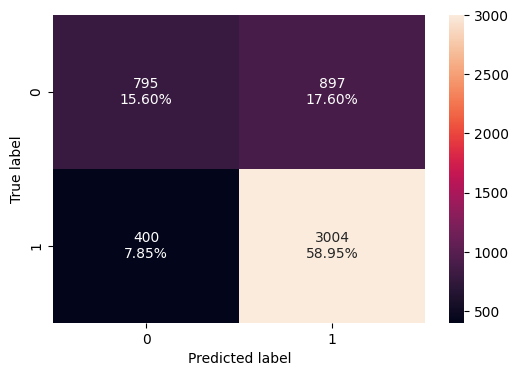

In [ ]:
# plotting confusion matrix for the best model on test data
confusion_matrix_sklearn(tuned_gbm_org, X_test, y_test)

* **True Negatives (TN)**: 795

* **False Positives (FP)**: 897

* **False Negatives (FN)**: 400

* **True Positives (TP)**: 3004

**Key Insights:**
- The model is very good at identifying Certified cases (high TP, low FN).

- There are more False Positives (897) than False Negatives (400), meaning the model sometimes predicts Certified when it should be Denied.

- Most Certified applications are correctly identified (3004 out of 3404 actual Certified).

- About half of Denied applications are misclassified as Certified (897 out of 1692 actual Denied).

In [ ]:
# checking the performance of the best model on test data
gbm_org_test_perf = model_performance_classification_sklearn(tuned_gbm_org, X_test, y_test)
gbm_org_test_perf

,Accuracy,Recall,Precision,F1
0,0.745487,0.882491,0.770059,0.82245


* **Model Performance on Unseen Data:**

    - **Accuracy (~75%):**
    The model correctly predicted the visa status for 75% of all applications.

    - **Recall (~88%):**
    Of all applications that were actually Certified, the model correctly identified 88%.
    Very few qualified applicants are missed by the model. This reduces the risk of overlooking strong candidates and minimizes manual review workload.

    - **Precision (~77%):**
    Of all applications the model predicted as Certified, 77% are actually certified.
    Most approvals made by the model are correct, but about 23% may be false positives (predicted certified but actually denied). This is a reasonable trade-off for high recall, but some manual review may still be needed for borderline cases.

    - **F1 Score (~82%):**
    The harmonic mean of precision and recall, showing a strong balance between catching most certified cases and not over-approving.

    - The model generalizes well, as evidenced by similar performance across training, validation, and test sets. This means the model can be trusted to perform consistently on new, real-world data.

### Feature Importances

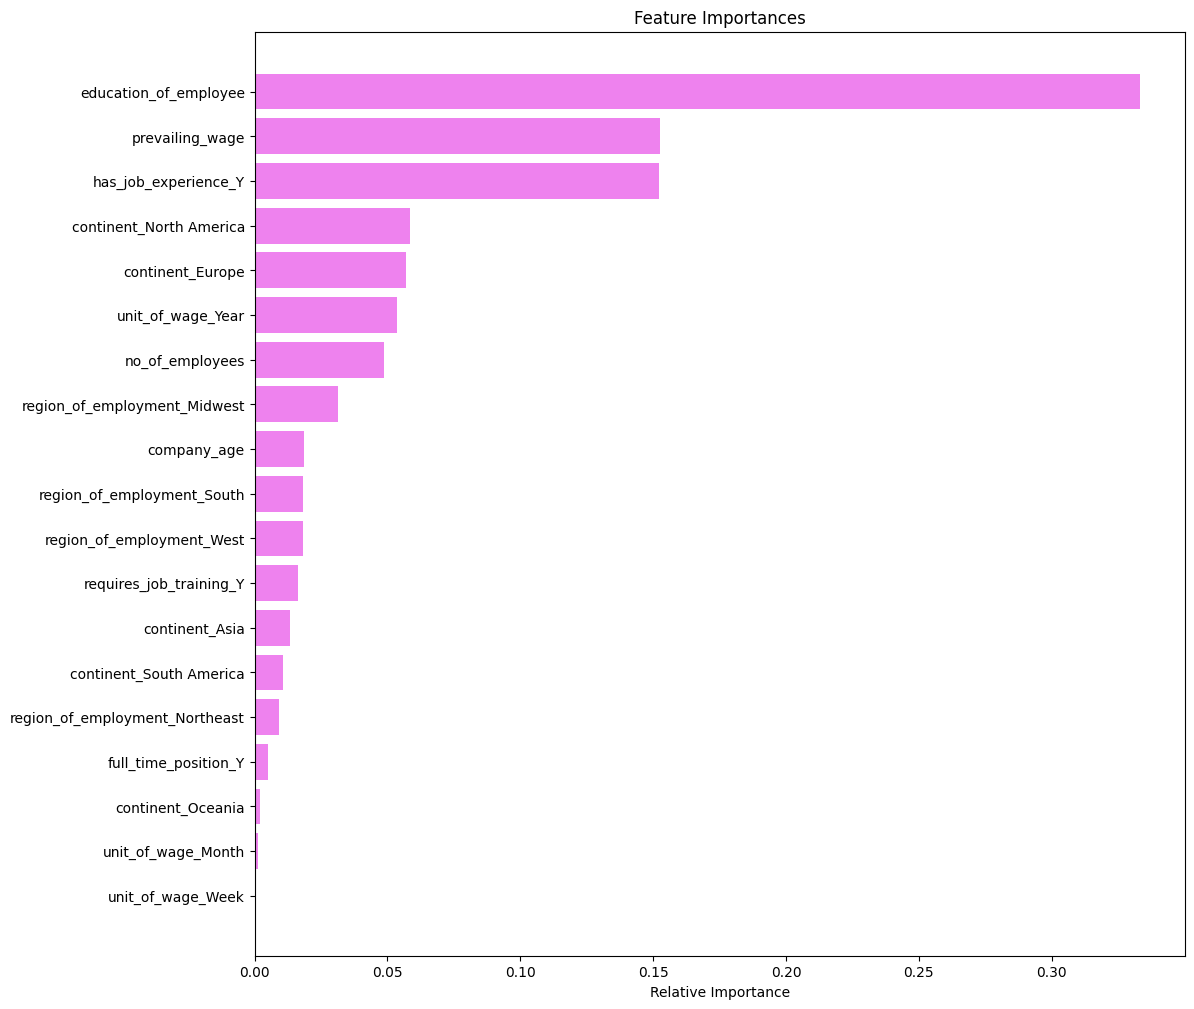

In [ ]:
feature_names = X_train.columns
importances = tuned_gbm_org.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

- **Employee's education**, **Prevailing wage** and **Job Experience** are the most important features for prediction.

# **Actionable Insights and Recommendations**

___

## **Key Actionable Insights**

* **Education is the Primary Driver:** Applicants with a **Master's or Doctorate degree** have significantly higher certification rates compared to those with only a High School education. Education was identified as one of the most important features.

* **Job Experience is Essential:** Candidates with **prior job experience** show a much higher likelihood of visa approval. Conversely, applicants requiring job training are frequently associated with higher denial rates.

* **Prevailing Wage Influence:** Higher prevailing wages are generally associated with certified cases. This suggests that the OFLC prioritizes high-value, specialized roles that do not compete with low-wage local labor.

* **Regional Performance:** The **Northeast and South regions** of the United States show the highest volume of applications and maintain favorable approval trends. The West region, while high in volume, suffers from a slightly higher denial rate compared to the Northeast.

* **Demographic Trends:** Approximately **66% of all applicants are from Asia**, making it the dominant source of talent for the firms in this dataset.

* **Company Stability:** Older, established companies (specifically those older than 50 years) tend to have a higher success rate in visa applications than newer startups.

## **Business Recommendations**

* **Target Highly Educated Talent:** To maximize the probability of visa certification, recruitment efforts should prioritize candidates who hold at least a **Master's degree**.

* **Prioritize Experienced Professionals:** Preference should be given to candidates who already possess relevant **job experience**, as this reduces the perceived risk and training burden during the OFLC evaluation.

* **Strategic Regional Placement:** For companies with multiple locations, filing applications for roles based in the **Northeast or South regions** may result in a smoother certification process based on historical trends.

* **Wage Benchmarking:** It is critical to ensure that the offered wage meets or exceeds the **prevailing wage** for the specific occupation. Underpaying foreign workers relative to the prevailing wage is a primary trigger for application denial.

* **Focus on Full-Time Roles:** Given that nearly **89% of applications are for full-time positions** and these see better certification rates, the business should focus its sponsorship efforts on full-time employment rather than part-time contracts.

## **Key Takeaways**
* **Top Predictors:** The most influential factors determining visa status are **education level, job experience, and prevailing wage**.

* **Ideal Candidate Profile:** The most "certifiable" applicant is one with a **Master's / Doctorate**, prior **job experience**, and a salary offer aligned with high **prevailing wages**.

* **Model Utilization:**
    - The tuned **Gradient Boosting** model trained on original dataset without oversampling provided the best predictive balance. The business can use the model to pre-screen applications with ~82% F1_Score and ~75% accuracy.

    - There is no need of complex resampling, as clean, well-prepared data led to the best results.

    - With a high Recall score (~88%) for Certified cases, most qualified applicants are not missed.

    - Moderate Precision score (~77%) indicates some Denied cases are incorrectly approved, so manual review may be needed for borderline cases.

    - The model is effective for prioritizing likely approvals but should be used with caution for automatic denials.